In [5]:
import json
import sys

from pathlib import Path
from datetime import datetime, timezone

import websocket

# ==============================================================================
# Import Protobuf Decoder
# ==============================================================================

PROTO_PATH = Path(
    r"D:\Data Projects\MEXC API Architecture\websocket-proto"
)

sys.path.append(str(PROTO_PATH))

from PushDataV3ApiWrapper_pb2 import PushDataV3ApiWrapper

# ==============================================================================
# WebSocket Configuration
# ==============================================================================

WS_URL = "wss://wbs-api.mexc.com/ws"

SYMBOL = "ETHUSDT"

ENDPOINT = f"spot@public.aggre.deals.v3.api.pb@10ms@{SYMBOL}"

subscription = {
    "method": "SUBSCRIPTION",
    "params": [
        ENDPOINT
    ],
    "id": 1
}

received_time = lambda: datetime.now(
    timezone.utc
).strftime("%Y-%m-%d %H:%M:%S.%f UTC")

# ==============================================================================
# Connect
# ==============================================================================

# ws = websocket.create_connection(WS_URL)

# ws.send(json.dumps(subscription))

# ==============================================================================
# Connect (To establish reconnection)
# ==============================================================================
def connect():
    """
    Establish a WebSocket connection to the MEXC market data server.

    This function:
    - Creates a new WebSocket connection.
    - Subscribes to the configured market data endpoint.
    - Retries automatically if the connection fails.

    Returns:
        websocket.WebSocket:
            An active WebSocket connection ready to receive data.

    Notes:
        This function is also used for automatic reconnection whenever
        the existing WebSocket connection is lost.
    """

    while True:

        try:
            ws = websocket.create_connection(WS_URL)

            ws.send(json.dumps(subscription))

            print(
                "Connected:",
                ENDPOINT
            )

            return ws

        except Exception as e:
            print(
                "Connection failed:",
                e
            )

            print(
                "Retrying in 3 seconds..."
            )

            time.sleep(3)

ws = connect()

# ==============================================================================
# Human-Readable Number Formatter
# ==============================================================================

def format_notional(value: float) -> str:
    """
    Convert a numeric value into a human-readable format.

    Examples
    --------
    532.45          -> 532.45
    12543.82        -> 12.54K
    3841256.71      -> 3.84M
    9823456789.12   -> 9.82B
    """

    if value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.2f}B"

    elif value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"

    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"

    else:
        return f"{value:.2f}"

Connected: spot@public.aggre.deals.v3.api.pb@10ms@ETHUSDT


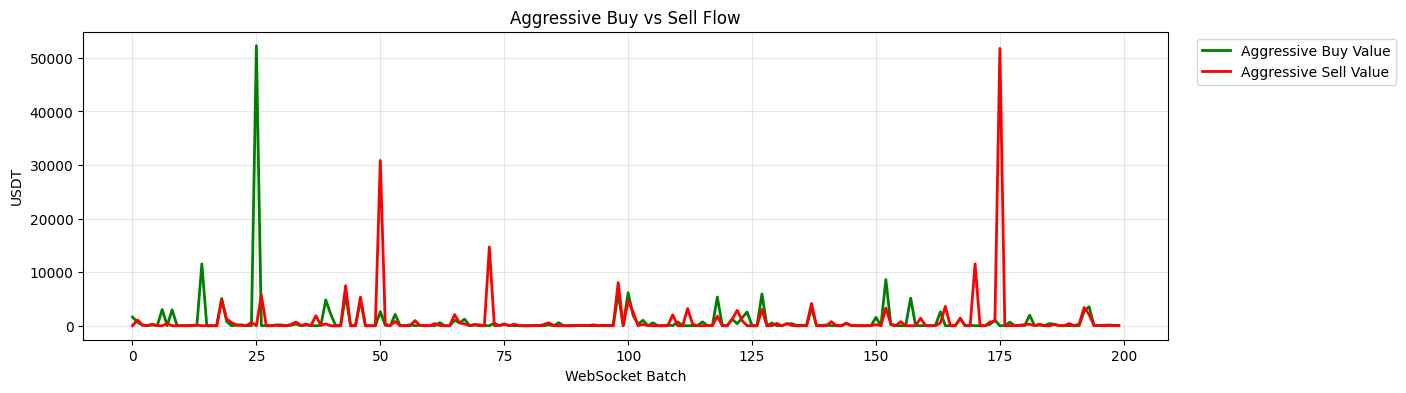

In [ ]:
# ==============================================================================
# Live Aggressive Buy / Sell Flow Chart
# ==============================================================================

import matplotlib.pyplot as plt

from collections import deque
from IPython.display import display, HTML


# ==============================================================================
# Chart Storage
# ==============================================================================

HISTORY_SIZE = 200

buy_history = deque(maxlen=HISTORY_SIZE)
sell_history = deque(maxlen=HISTORY_SIZE)

# ==============================================================================
# Fixed Display
# ==============================================================================

dashboard_display = display(
    HTML(""),
    display_id=True
)

chart_display = display(
    HTML(""),
    display_id=True
)

# ==============================================================================
# Create Chart
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(14, 4)
)

buy_line, = ax.plot(
    [],
    [],
    color="green",
    linewidth=2,
    label="Aggressive Buy Value"
)

sell_line, = ax.plot(
    [],
    [],
    color="red",
    linewidth=2,
    label="Aggressive Sell Value"
)

ax.set_title(
    "Aggressive Buy vs Sell Flow"
)

ax.set_xlabel(
    "WebSocket Batch"
)

ax.set_ylabel(
    "USDT"
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

ax.grid(
    True,
    alpha=0.3
)

# ==============================================================================
# Update Chart Function
# ==============================================================================

def update_flow_chart(
    batch_buy_value,
    batch_sell_value
):

    buy_history.append(batch_buy_value)

    sell_history.append(batch_sell_value)

    x_values = range(
        len(buy_history)
    )

    buy_line.set_data(
        x_values,
        buy_history
    )

    sell_line.set_data(
        x_values,
        sell_history
    )

    ax.relim()

    ax.autoscale_view()

    fig.canvas.draw_idle()

# ==============================================================================
# Receive Loop
# ==============================================================================

cumulative_delta = 0.0

while True:

    # ==========================================================================
    # Receive Message
    # ==========================================================================

    # message = ws.recv()

    # if isinstance(message, str):
        # continue
    try:
        message = ws.recv()

    except Exception as e:
        print(
            "Connection lost:",
            e
        )
        try:
            ws.close()

        except:
            pass

        ws = connect()
        continue

    if isinstance(message, str):

        continue
    
    # ==========================================================================
    # Decode Message
    # ==========================================================================
    wrapper = PushDataV3ApiWrapper()
    wrapper.ParseFromString(
        message
    )

    trades = wrapper.publicAggreDeals

    exchange_timestamp = datetime.fromtimestamp(
        wrapper.sendTime / 1000,
        tz=timezone.utc
    )

    receive_timestamp = received_time()

    # ==========================================================================
    # Dashboard Storage
    # ==========================================================================
    dashboard = []

    dashboard.append("=" * 100)

    dashboard.append("TRADE EXECUTIONS")

    dashboard.append("=" * 100)

    dashboard.append(f"Exchange Time : {exchange_timestamp}")

    dashboard.append(f"Receive Time  : {receive_timestamp}")

    dashboard.append("-" * 124)

    dashboard.append(
        f"{'Price':>12}"
        f"{'Quantity(ETH)':>18}"
        f"{'Value(USDT)':>18}"
        f"{'Side':>12}"
        f"{'Running Delta':>20}"
        f"{'Cumulative Delta':>24}"
    )

    dashboard.append("-" * 124)

    # ==========================================================================
    # Batch Variables
    # ==========================================================================

    running_delta = 0.0

    batch_buy_value = 0.0

    batch_sell_value = 0.0

    # ==========================================================================
    # Process Trade Executions
    # ==========================================================================

    for trade in trades.deals:

        price = float(trade.price)

        quantity = float(trade.quantity)

        value = price * quantity

        side = (
            "BUY"
            if trade.tradeType == 1
            else "SELL"
        )

        # ======================================================================
        # Update Statistics
        # ======================================================================

        if side == "BUY":

            batch_buy_value += value
            running_delta += value
            cumulative_delta += value
        else:
            batch_sell_value += value
            running_delta -= value
            cumulative_delta -= value

        # ======================================================================
        # Add Trade Row
        # ======================================================================

        dashboard.append(
            f"{price:>12.2f}"
            f"{quantity:>18.5f}"
            f"{format_notional(value):>18}"
            f"{side:>12}"
            f"{('+' if running_delta >= 0 else '-') + format_notional(abs(running_delta)):>20}"
            f"{('+' if cumulative_delta >= 0 else '-') + format_notional(abs(cumulative_delta)):>24}"
        )

    # ==========================================================================
    # Batch Summary
    # ==========================================================================

    trade_delta = (
        batch_buy_value
        -
        batch_sell_value
    )

    dashboard.append("-" * 124)

    dashboard.append("BATCH SUMMARY")

    dashboard.append("-" * 124)

    dashboard.append(
        f"{'Aggressive Buy Value':<30}: "
        f"{format_notional(batch_buy_value)}"
    )

    dashboard.append(
        f"{'Aggressive Sell Value':<30}: "
        f"{format_notional(batch_sell_value)}"
    )

    dashboard.append(
        f"{'Trade Delta':<30}: "
        f"{('+' if trade_delta >= 0 else '-')}"
        f"{format_notional(abs(trade_delta))}"
    )

    dashboard.append(
        f"{'Session Cumulative Delta':<30}: "
        f"{('+' if cumulative_delta >= 0 else '-')}"
        f"{format_notional(abs(cumulative_delta))}"
    )

    dashboard.append("=" * 100)

    # ==========================================================================
    # Update Dashboard Display
    # ==========================================================================

    dashboard_display.update(
        HTML(
            "<pre>"
            +
            "\n".join(dashboard)
            +
            "</pre>"
        )
    )

    # ==========================================================================
    # Update Buy / Sell Flow Chart
    # ==========================================================================

    update_flow_chart(
        batch_buy_value,
        batch_sell_value
    )

    chart_display.update(
        fig
    )